<a href="https://colab.research.google.com/github/tusharviradiya/ai-ml/blob/main/11_Practice/week2/Binary_Classification_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ==============================================================================
# 1. SETUP & DATA LOADING
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# Active Kaggle Telco Customer Churn raw mirror
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# ==============================================================================
# 2. DATA CLEANING & PREPROCESSING
# ==============================================================================
# Drop non-predictive ID column safely (won't crash if re-run)
df.drop(columns=["customerID"], errors="ignore", inplace=True)

# Fix whitespace values in TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(), errors="coerce"
)
df.dropna(subset=["TotalCharges"], inplace=True)

# Encode binary target if not already encoded
if df["Churn"].dtype == object:
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-Hot Encode remaining categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Train / Validation / Test Split (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete!")
print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")

Preprocessing complete!
X_train shape: (4922, 30), y_train shape: (4922,)


In [13]:
# ==============================================================================
# 3. MODEL TRAINING & PREDICTION
# ==============================================================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

--- Test Set Evaluation ---
Accuracy:  0.7896
Precision: 0.6208
Recall:    0.5321
F1-Score:  0.5731
ROC-AUC:   0.8221

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       775
           1       0.62      0.53      0.57       280

    accuracy                           0.79      1055
   macro avg       0.73      0.71      0.72      1055
weighted avg       0.78      0.79      0.78      1055



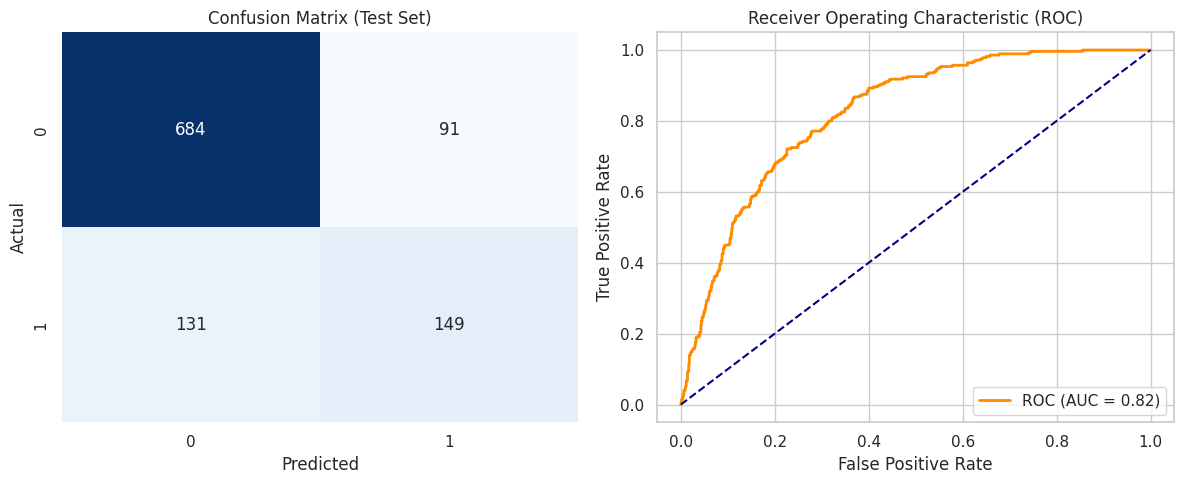

In [14]:
# ==============================================================================
# 4. EVALUATION METRICS & VISUALIZATIONS
# ==============================================================================
print("--- Test Set Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_test_pred))

# Confusion Matrix & ROC Curve Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0])
ax[0].set_title("Confusion Matrix (Test Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax[1].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC (AUC = {roc_auc_score(y_test, y_test_proba):.2f})",
)
ax[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
ax[1].set_title("Receiver Operating Characteristic (ROC)")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

Train Accuracy: 0.8058 | Validation Accuracy: 0.8246 | Test Accuracy: 0.7896


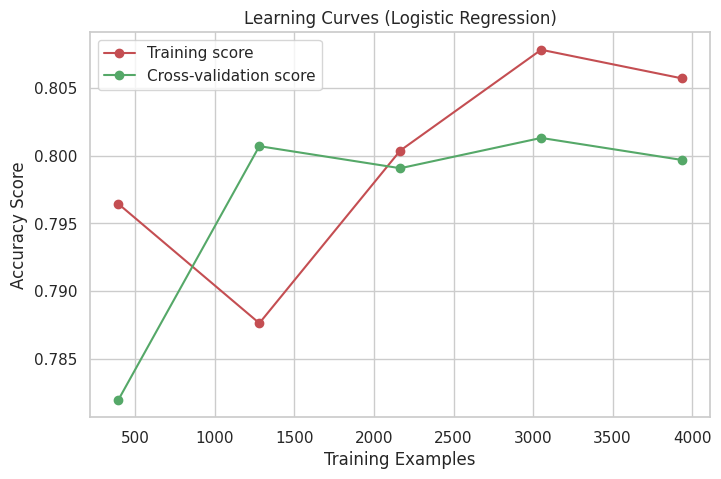

In [15]:
# ==============================================================================
# 5. OVERFITTING & UNDERFITTING DIAGNOSTICS
# ==============================================================================
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(
    f"Train Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} | Test Accuracy: {test_acc:.4f}"
)

# Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    "o-",
    color="r",
    label="Training score",
)
plt.plot(
    train_sizes,
    np.mean(val_scores, axis=1),
    "o-",
    color="g",
    label="Cross-validation score",
)
plt.title("Learning Curves (Logistic Regression)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.show()

# Diagnostic conclusion:
# If Train Acc ≈ Val Acc with steady convergence, the model shows low variance (no overfitting).